## 1. Giới thiệu về Tập dữ liệu (Introduction)
Tập dữ liệu **CIFAR-10** là một bộ sưu tập các hình ảnh được sử dụng phổ biến trong các bài toán thị giác máy tính.
* Quy mô: 60.000 hình ảnh màu kích thước 32x32 pixel.
* Phân loại: 10 lớp đối tượng (máy bay, ô tô, chim, mèo, nai, chó, ếch, ngựa, tàu thủy, xe tải).
* Cấu trúc: 50.000 ảnh huấn luyện và 10.000 ảnh kiểm thử.
* Đặc điểm: Mỗi lớp có chính xác 6.000 hình ảnh, tạo nên một tập dữ liệu cân bằng hoàn hảo.

In [1]:
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
# %pip install numpy matplotlib seaborn pandas tqdm

## 2. Phương pháp nghiên cứu

Quy trình thực hiện được thiết kế chặt chẽ nhằm tối ưu hóa hiệu suất mô hình trên tập dữ liệu nhỏ:

1. Trích xuất và tiền xử lý dữ liệu từ file .tar.gz
2. Tái cấu trúc dữ liệu về định dạng tensor 4 chiều `(N, 32, 32, 3)`
3. Phân tích khám phá dữ liệu (EDA)
4. Tiền xử lý & Tăng cường dữ liệu (Data Augmentation)
5. Xây dựng và huấn luyện mô hình (Transfer Learning + Fine-tuning)
6. Đánh giá và so sánh kết quả

### 2.1. Các kỹ thuật nâng cao được áp dụng

**Transfer Learning**
- Sử dụng **ResNet50** và **Vision Transformer** được pre-trained trên ImageNet.
- **Freeze Backbone**: Giữ nguyên trọng số tầng convolutional, chỉ huấn luyện phần classifier.
- **Fine-tune**: Mở một phần hoặc toàn bộ backbone với learning rate nhỏ.

**Data Augmentation**
- **Standard Augmentation**: RandomHorizontalFlip, RandomRotation, RandomCrop, Normalization.

**Regularization**
- Label Smoothing
- Weight Decay (L2)
- Warmup + Cosine Learning Rate Decay

## 3. Triển khai Mã nguồn (Implementation)

### 3.1. Giải nén và Chuẩn bị dữ liệu

CIFAR-10 được cung cấp dưới dạng file `.tar.gz` chứa 6 batch nhị phân (5 batch train + 1 batch test). Mỗi batch có:
- `data`: mảng (10000, 3072) — ảnh đã được flatten.
- `labels`: danh sách nhãn từ 0 đến 9.

In [2]:
import os

# Source path from the file system
source_path = './cifar-10-python.tar.gz'
dest_path = './cifar-10-python.tar.gz'

if os.path.exists(source_path):
    !cp {source_path} {dest_path}
    print(f"Copied {source_path} to current directory.")
else:
    print("File not found in current directory, downloading from source...")
    !wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

cp: './cifar-10-python.tar.gz' and './cifar-10-python.tar.gz' are the same file
Copied ./cifar-10-python.tar.gz to current directory.


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
import tarfile
import os

# Tên file đã tải xuống từ bước 3.1
file_name = 'cifar-10-python.tar.gz'
output_dir = './output_folder'

if os.path.exists(file_name):
    with tarfile.open(file_name, 'r:gz') as tar:
        tar.extractall(path=output_dir)
        print(f"Đã giải nén thành công vào {output_dir}")
else:
    print("Lỗi: Không tìm thấy file cifar-10-python.tar.gz. Hãy chạy lại cell tải dữ liệu ở mục 3.1.")

/tmp/ipykernel_2070/2058467999.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_dir)


Đã giải nén thành công vào ./output_folder


### 3.2. Nạp và Tái cấu trúc Dữ liệu

Dữ liệu gốc là vector phẳng 3072 chiều. Ta thực hiện reshape và transpose để chuyển về định dạng tensor phù hợp với Keras/TensorFlow:

```python
(50000, 3072) → (50000, 3, 32, 32) → (50000, 32, 32, 3)

In [5]:
import pickle
import numpy as np
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [6]:
import os
import numpy as np

def load_cifar10_data(data_dir):
    train_data = []
    train_labels = []

    # Load đủ 5 training batches
    for i in range(1, 6):
        batch_path = os.path.join(data_dir, f'data_batch_{i}')
        batch = unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    X_train = np.concatenate(train_data)
    y_train = np.array(train_labels)

    # Load test batch
    test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
    X_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    return X_train, y_train, X_test, y_test

# Đường dẫn chuẩn sau khi giải nén file gốc
data_folder = './output_folder/cifar-10-batches-py'

if os.path.exists(data_folder):
    X_train, y_train, X_test, y_test = load_cifar10_data(data_folder)
    print(f"Nạp dữ liệu Numpy thành công. X_train shape: {X_train.shape}")
else:
    print(f"Lỗi: Không tìm thấy thư mục {data_folder}. Hãy kiểm tra lại bước giải nén.")

/tmp/ipykernel_2070/931817816.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Nạp dữ liệu Numpy thành công. X_train shape: (50000, 3072)


In [7]:
import torch

def reshape_cifar_torch(data):
    # PyTorch sử dụng định dạng (N, C, H, W)
    # 1. Reshape từ vector phẳng (3072) -> (3, 32, 32)
    data = data.reshape(-1, 3, 32, 32)
    # Chuyển thành Torch Tensor và chuẩn hóa về [0, 1]
    return torch.from_numpy(data).float() / 255.0

X_train = reshape_cifar_torch(X_train)
X_test = reshape_cifar_torch(X_test)
y_train = torch.tensor(y_train).long()
y_test = torch.tensor(y_test).long()

print(f"Final Torch Shape: {X_train.shape}") # (50000, 3, 32, 32)

Final Torch Shape: torch.Size([50000, 3, 32, 32])


### 3.3. Phân tích Dữ liệu Khám phá (EDA)

Kiểm tra sự cân bằng của các lớp và đặc điểm thống kê của pixel.

#### 3.3.1. Kiểm tra sự phân bổ các lớp

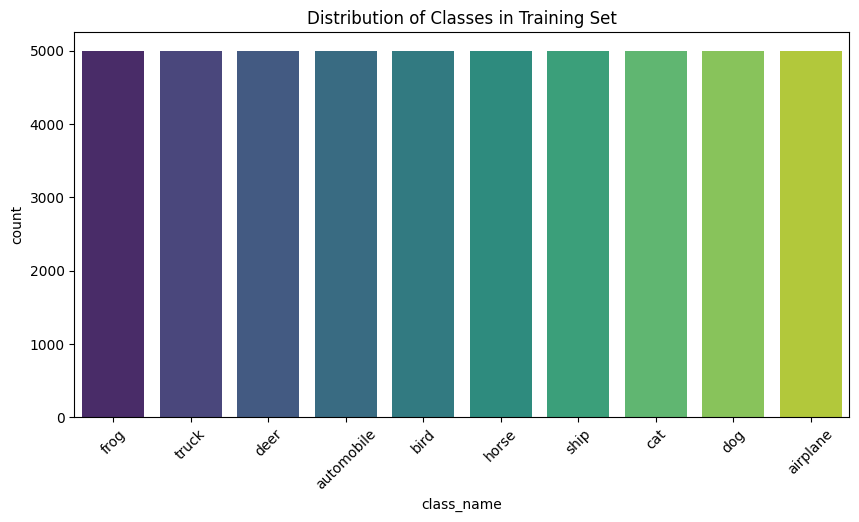

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a DataFrame for easy plotting
df_train = pd.DataFrame(y_train, columns=['label'])
df_train['class_name'] = df_train['label'].apply(lambda x: label_names[x])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='class_name', hue='class_name', palette='viridis', legend=False)
plt.title('Distribution of Classes in Training Set')
plt.xticks(rotation=45)
plt.show()

**Nhận xét từ EDA**:
- Mỗi lớp có đúng 5000 ảnh trong tập train → dataset **hoàn toàn cân bằng**.
- Không cần xử lý class imbalance.

#### 3.3.2. Kiểm tra tính toàn vẹn trực quan

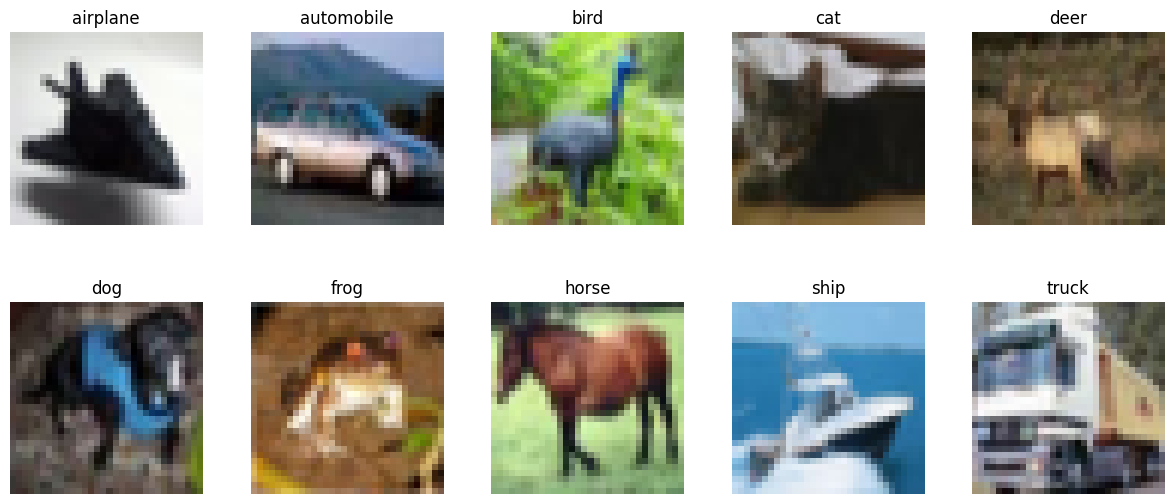

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Tìm ảnh đầu tiên của mỗi lớp
    idx = torch.where(y_train == i)[0][0]
    # Chuyển từ (C, H, W) -> (H, W, C) để Matplotlib có thể hiển thị
    img = X_train[idx].permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(label_names[i])
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

#### 3.3.3. Phân tích phân phối pixel theo từng kênh màu (RGB)

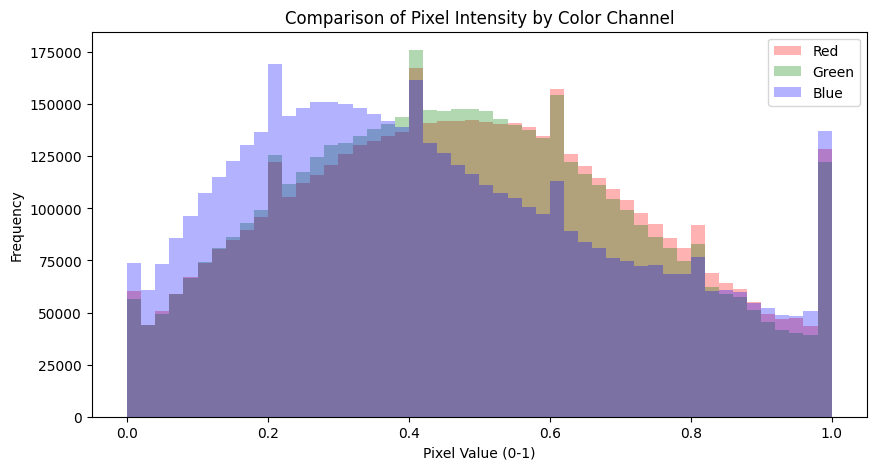

Red Channel - Mean: 0.4902, Std: 0.2482
Green Channel - Mean: 0.4811, Std: 0.2443
Blue Channel - Mean: 0.4452, Std: 0.2613


In [10]:
# Sample for speed
sample_idx = np.random.choice(len(X_train), 5000)
sample_data = X_train[sample_idx] # Shape (5000, 3, 32, 32)

plt.figure(figsize=(10, 5))
# Plot Red, Green, and Blue distributions
# PyTorch: [N, C, H, W] -> C=0: Red, C=1: Green, C=2: Blue
plt.hist(sample_data[:, 0, :, :].flatten().numpy(), bins=50, color='red', alpha=0.3, label='Red')
plt.hist(sample_data[:, 1, :, :].flatten().numpy(), bins=50, color='green', alpha=0.3, label='Green')
plt.hist(sample_data[:, 2, :, :].flatten().numpy(), bins=50, color='blue', alpha=0.3, label='Blue')

plt.legend()
plt.title("Comparison of Pixel Intensity by Color Channel")
plt.xlabel("Pixel Value (0-1)")
plt.ylabel("Frequency")
plt.show()

# Calculate mean and std for each channel (dim 0, 2, 3 are N, H, W)
mean = sample_data.mean(dim=(0, 2, 3))
std = sample_data.std(dim=(0, 2, 3))

# Print specific stats for your report
for i, color in enumerate(['Red', 'Green', 'Blue']):
    print(f"{color} Channel - Mean: {mean[i]:.4f}, Std: {std[i]:.4f}")

### 3.4. Tiền xử lý dữ liệu (Data Preprocessing)
**Các bước chính**:
- Chuẩn hóa pixel về khoảng `[0, 1]`
- One-hot encoding nhãn
- Phân tách tập validation (80/20)
- Data Augmentation (Standard)


In [11]:
from torch.utils.data import DataLoader, TensorDataset, random_split

X_train_norm = X_train.float() / 255.0 if X_train.max() > 1.0 else X_train.float()
X_test_norm = X_test.float() / 255.0 if X_test.max() > 1.0 else X_test.float()
# 1. Tạo Dataset
full_train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset = TensorDataset(X_test_norm, y_test)

# 2. Phân tách tập Validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Preprocessing Complete (PyTorch).")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Preprocessing Complete (PyTorch).
Train samples: 40000, Val samples: 10000, Test samples: 10000


Vì hình ảnh CIFAR-10 có độ phân giải thấp, mô hình rất dễ bị "overfitting". Vì vậy, nhóm sử dụng `ImageDataGenerator` để thực hiện các phép biến đổi ngẫu nhiên ngay trong quá trình huấn luyện.

In [12]:
from torchvision import transforms
from torch.utils.data import Dataset

class AugmentedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

# Định nghĩa các phép biến đổi Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Đưa về dải quanh số 0
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Khởi tạo DataLoader
BATCH_SIZE = 128
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.dataset)

# KHỞI TẠO DATALOADER (Thấy rõ Loader ở đây)
train_loader = DataLoader(AugmentedDataset(train_dataset, train_transform), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AugmentedDataset(val_dataset, test_transform), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(AugmentedDataset(test_dataset, test_transform), batch_size=BATCH_SIZE, shuffle=False)

print("✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!")

✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Batch shape: torch.Size([128, 3, 32, 32]) dtype: torch.float32 min: -1.0 max: 1.0


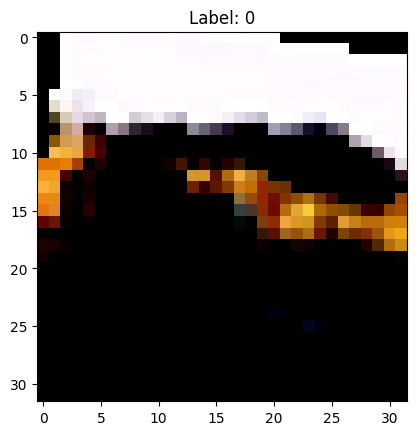

In [13]:
for batch_X, batch_y in train_loader:
    print("Batch shape:", batch_X.shape, "dtype:", batch_X.dtype, "min:", batch_X.min().item(), "max:", batch_X.max().item())
    import matplotlib.pyplot as plt
    img = batch_X[0].permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    plt.title(f"Label: {batch_y[0].item()}")
    plt.show()
    break

**Kiểm tra trực quan sau tiền xử lý (Final Sanity Check)**

Bước này đảm bảo rằng sau tất cả các bước tải, tái cấu trúc, chuẩn hóa và mã hóa, dữ liệu vẫn giữ được ý nghĩa logic.

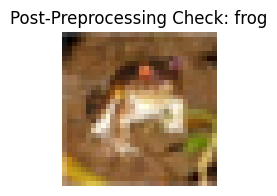

Pixel Range: [0.00, 1.00] 


In [14]:
# Map integer labels to names based on the CIFAR-10 documentation
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(5,2))
# 1. Chuyển đổi từ (C, H, W) sang (H, W, C) để hiển thị
img_to_show = X_train[0].permute(1, 2, 0).numpy()
plt.imshow(img_to_show)

# 2. Lấy nhãn trực tiếp từ Tensor (PyTorch lưu nhãn dạng integer)
current_label = label_names[y_train[0].item()]

plt.title(f"Post-Preprocessing Check: {current_label}")
plt.axis('off')
plt.show()

print(f"Pixel Range: [{X_train[0].min():.2f}, {X_train[0].max():.2f}] ") # Should be [0.0, 1.0]

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Các thông số cấu hình chung
num_classes = 10
# Lưu ý: PyTorch sử dụng (Channels, Height, Width)
input_shape = (3, 32, 32)

print(f"Huấn luyện sẽ được thực hiện trên các DataLoader PyTorch.")
print(f"Batch size: {BATCH_SIZE}")
print(f"Số lượng lớp: {num_classes}")

Huấn luyện sẽ được thực hiện trên các DataLoader PyTorch.
Batch size: 128
Số lượng lớp: 10


# 6. Các kiến trúc kết hợp và cách embed ảnh khác nhau

6.1. Xây dựng một số kiến trúc phân loại cho cùng tập dữ liệu theo hai hướng khác nhau.


*   Kết hợp CNN và Transformer: ví dụ dùng CNN làm backbone trích đặc trưng, sau đó chuỗi đặc trưng đưa vào Transformer; hoặc ngược lại.
*   Các cách tokenizer và embed ảnh khác nhau: patch theo ô lưới; patch có overlap; patch kích thước khác nhau.

6.2. Huấn luyện, đánh giá và so sánh các kiểu xây dựng mô hình (bảng số liệu, biểu đồ, nhận xét).

In [22]:
import torch
import torch.nn as nn

class CNNStem(nn.Module):
    """Trích xuất Feature Map từ ảnh thô"""
    def __init__(self, in_channels=3, out_channels=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels // 2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels // 2),
            nn.ReLU(),
            nn.Conv2d(out_channels // 2, out_channels, kernel_size=3, stride=2, padding=1), # 16x16
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.conv(x)

class HybridViT(nn.Module):
    def __init__(self, num_classes=10, embed_dim=128, num_heads=4, num_layers=4):
        super().__init__()
        self.stem = CNNStem(out_channels=embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 16 * 16, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=256, dropout=0.1,)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        B, C, H, W = x.shape
        x = x.view(B, C, H * W).permute(0, 2, 1)
        x = x + self.pos_embedding
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridViT().to(device)

In [ ]:
import torch
import os

class TrainingManager:
    def __init__(self, model_name="HybridViT_CIFAR10", patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_acc_max = 0
        self.model_path = f"{model_name}_best.pth"

    def __call__(self, val_acc, model):
        score = val_acc

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_acc, model)
            self.counter = 0

    def save_checkpoint(self, val_acc, model):
        """Lưu model khi Validation Accuracy tăng"""
        if self.verbose:
            print(f"Validation accuracy increased ({self.val_acc_max:.4f} --> {val_acc:.4f}). Saving model...")
        torch.save(model.state_dict(), self.model_path)
        self.val_acc_max = val_acc

# --- Khởi tạo ---
manager = TrainingManager(patience=15) 

In [24]:
import torch
import torch.nn.functional as F
import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for batch_X, batch_y in tqdm.tqdm(loader, desc="Training", total=len(loader)):
        inputs = batch_X.to(device)
        targets = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [25]:
import time
# Training config
LR = 1e-4
EPOCHS = 20
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

start_time = time.time()
hist_cnn_transformer = {"train_loss": [], "val_acc": []}

for epoch in range(EPOCHS):    
    # 1. Train
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device,
    )

    # 2. Evaluate (validation)
    model.eval()
    correct = 0
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X = val_X.to(device)
            val_y = val_y.to(device)
            outputs = model(val_X)
            preds = outputs.argmax(1)
            correct += (preds == val_y).sum().item()

    val_acc = correct / len(val_dataset)
    current_lr = optimizer.param_groups[0]['lr']

    hist_cnn_transformer["train_loss"].append(train_loss)
    hist_cnn_transformer["val_acc"].append(val_acc)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {train_loss:.4f} - Val Acc: {val_acc:.4f} - LR: {current_lr:.6f}")

    # 3. Checkpoint & Early Stopping
    manager(val_acc, model)

    if manager.early_stop:
        print("Early stopping triggered. Kết thúc huấn luyện sớm.")
        break

    # 4. Update Scheduler
    scheduler.step()

training_total_time = time.time() - start_time
print(f"Huấn luyện hoàn tất trong {training_total_time:.2f} giây")

# Sau khi xong, load lại trọng số tốt nhất (map_location để an toàn)
model.load_state_dict(torch.load(manager.model_path, map_location=device))
print(f"Đã load trọng số tốt nhất với Accuracy: {manager.val_acc_max:.4f}")

Training: 100%|██████████| 313/313 [00:43<00:00,  7.27it/s]


Epoch [1/20] - Loss: 1.9200 - Val Acc: 0.3580 - LR: 0.000100
Validation accuracy increased (0.0000 --> 0.3580). Saving model...


Training: 100%|██████████| 313/313 [00:41<00:00,  7.48it/s]


Epoch [2/20] - Loss: 1.7392 - Val Acc: 0.4344 - LR: 0.000099
Validation accuracy increased (0.3580 --> 0.4344). Saving model...


Training: 100%|██████████| 313/313 [00:41<00:00,  7.48it/s]


...

Epoch [18/20] - Loss: 1.3681 - Val Acc: 0.6223 - LR: 0.000005
EarlyStopping counter: 1 out of 15


Training: 100%|██████████| 313/313 [00:41<00:00,  7.47it/s]


Epoch [19/20] - Loss: 1.3633 - Val Acc: 0.6229 - LR: 0.000002
Validation accuracy increased (0.6229 --> 0.6229). Saving model...


Training: 100%|██████████| 313/313 [00:41<00:00,  7.45it/s]


Epoch [20/20] - Loss: 1.3600 - Val Acc: 0.6246 - LR: 0.000001
Validation accuracy increased (0.6229 --> 0.6246). Saving model...
Huấn luyện hoàn tất trong 880.17 giây
Đã load trọng số tốt nhất với Accuracy: 0.6246


In [20]:
# %% [markdown]
# ## 6.2. Các cách Tokenizer và Embed ảnh khác nhau
#
# Ba phương pháp patch embedding được hiện thực và so sánh:
# 1. **Grid Patch** – Chia ảnh thành các ô lưới không chồng lấp (tiêu chuẩn ViT).
# 2. **Overlapping Patch** – Patch có stride nhỏ hơn patch size, tạo vùng overlap.
# 3. **Multi-Scale Patch** – Trích patch ở nhiều kích thước khác nhau, chiếu về cùng chiều embedding.

# %%
import torch
import torch.nn as nn
import math


# ─────────────────────────────────────────────────────
# 1. Grid Patch Embedding (ô lưới, không overlap)
#    Giống ViT gốc: chia ảnh 32×32 thành các patch p×p
#    không chồng lấp (stride = patch_size).
#    Số token = (H/p) × (W/p)
# ─────────────────────────────────────────────────────
class GridPatchEmbedding(nn.Module):
    """
    Patch theo ô lưới – stride = patch_size, không overlap.
    Với CIFAR-10 (32×32) và patch_size=4: 8×8 = 64 token.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        assert img_size % patch_size == 0, "img_size phải chia hết cho patch_size"
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d với kernel=stride=patch_size ≡ linear projection từng patch
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)                         # (B, embed_dim, H/p, W/p)
        B, E, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)         # (B, num_patches, embed_dim)
        x = x + self.pos_embed
        return x                                  # (B, 64, 128) với p=4, d=128


# ─────────────────────────────────────────────────────
# 2. Overlapping Patch Embedding (patch có overlap)
#    stride < patch_size tạo ra vùng chồng lấp.
#    Số token = ((H - patch_size)/stride + 1)^2
#    Ví dụ: patch_size=8, stride=4 → ((32-8)/4+1)^2 = 49 token
# ─────────────────────────────────────────────────────
class OverlapPatchEmbedding(nn.Module):
    """
    Patch có overlap – stride < patch_size.
    Bắt được nhiều ngữ cảnh cục bộ hơn Grid Patch.
    """
    def __init__(self, img_size=32, patch_size=8, stride=4,
                 in_channels=3, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.stride = stride
        num_p = ((img_size - patch_size) // stride + 1) ** 2
        self.num_patches = num_p
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=stride,
                              padding=0)
        self.pos_embed = nn.Parameter(torch.randn(1, num_p, embed_dim))

    def forward(self, x):
        x = self.proj(x)                         # (B, embed_dim, H', W')
        B, E, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)         # (B, num_patches, embed_dim)
        x = x + self.pos_embed
        return x                                  # (B, 49, 128)


# ─────────────────────────────────────────────────────
# 3. Multi-Scale Patch Embedding (patch kích thước khác nhau)
#    Trích patch ở p=4 (fine), p=8 (medium), p=16 (coarse).
#    Mỗi scale chiếu về cùng embed_dim rồi concatenate.
#    Cung cấp thông tin đa độ phân giải (như FPN/PVT).
# ─────────────────────────────────────────────────────
class MultiScalePatchEmbedding(nn.Module):
    """
    Patch kích thước khác nhau: fine (p=4), medium (p=8), coarse (p=16).
    Tất cả scale chiếu về embed_dim, ghép theo chiều token.
    Tổng token = 64 + 16 + 4 = 84.
    """
    def __init__(self, img_size=32, in_channels=3, embed_dim=128):
        super().__init__()
        # (patch_size, stride) cho từng scale
        scales = [(4, 4), (8, 8), (16, 16)]
        self.branches = nn.ModuleList()
        total_patches = 0
        self.patch_counts = []

        for ps, st in scales:
            num_p = ((img_size - ps) // st + 1) ** 2
            total_patches += num_p
            self.patch_counts.append(num_p)
            self.branches.append(
                nn.Conv2d(in_channels, embed_dim,
                          kernel_size=ps, stride=st, padding=0)
            )

        self.num_patches = total_patches
        self.pos_embed = nn.Parameter(torch.randn(1, total_patches, embed_dim))

    def forward(self, x):
        tokens = []
        for branch in self.branches:
            t = branch(x)                        # (B, E, H', W')
            B, E, H, W = t.shape
            t = t.flatten(2).transpose(1, 2)     # (B, num_p_scale, E)
            tokens.append(t)
        x = torch.cat(tokens, dim=1)             # (B, 84, embed_dim)
        x = x + self.pos_embed
        return x


# ─────────────────────────────────────────────────────
# Transformer Classifier dùng chung cho cả 3 embedding
# ─────────────────────────────────────────────────────
class PatchTransformer(nn.Module):
    """
    Backbone Transformer nhận chuỗi token từ bất kỳ embedding nào.
    Mean-pool các token → Linear classifier.
    """
    def __init__(self, embedder: nn.Module, embed_dim=128,
                 num_heads=4, num_layers=4, num_classes=10):
        super().__init__()
        self.embedder = embedder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=256, dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        tokens = self.embedder(x)                # (B, N, D)
        tokens = self.transformer(tokens)        # (B, N, D)
        pooled = tokens.mean(dim=1)              # (B, D)
        return self.classifier(pooled)           # (B, num_classes)


# ─────────────────────────────────────────────────────
# Khởi tạo 3 mô hình
# ─────────────────────────────────────────────────────
EMBED_DIM = 128
NUM_CLASSES = 10

embedder_grid    = GridPatchEmbedding(embed_dim=EMBED_DIM)
embedder_overlap = OverlapPatchEmbedding(embed_dim=EMBED_DIM)
embedder_multi   = MultiScalePatchEmbedding(embed_dim=EMBED_DIM)

model_grid    = PatchTransformer(embedder_grid,    embed_dim=EMBED_DIM,
                                 num_classes=NUM_CLASSES).to(device)
model_overlap = PatchTransformer(embedder_overlap, embed_dim=EMBED_DIM,
                                 num_classes=NUM_CLASSES).to(device)
model_multi   = PatchTransformer(embedder_multi,   embed_dim=EMBED_DIM,
                                 num_classes=NUM_CLASSES).to(device)

# ─────────────────────────────────────────────────────
# Kiểm tra số token và param count
# ─────────────────────────────────────────────────────
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("=" * 60)
print(f"{'Mô hình':<25} {'Số token':>10} {'Params':>12}")
print("=" * 60)
print(f"{'Grid Patch':<25} {embedder_grid.num_patches:>10} {count_params(model_grid):>12,}")
print(f"{'Overlap Patch':<25} {embedder_overlap.num_patches:>10} {count_params(model_overlap):>12,}")
print(f"{'Multi-Scale Patch':<25} {embedder_multi.num_patches:>10} {count_params(model_multi):>12,}")
print("=" * 60)

# Sanity-check forward pass
dummy = torch.randn(4, 3, 32, 32).to(device)
for name, m in [("Grid", model_grid), ("Overlap", model_overlap), ("Multi", model_multi)]:
    out = m(dummy)
    print(f"[{name}] Output shape: {out.shape}")  # mong đợi (4, 10)


# ─────────────────────────────────────────────────────
# Hàm huấn luyện chung (tái sử dụng train_one_epoch)
# ─────────────────────────────────────────────────────
def train_patch_model(model, model_name, epochs=20, lr=1e-4, wd=1e-4):
    """Huấn luyện một mô hình patch-embedding và trả về lịch sử acc."""
    mgr = TrainingManager(model_name=model_name, patience=15, verbose=False)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # Train
        loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

        # Validate
        model.eval()
        correct = 0
        with torch.no_grad():
            for vX, vy in val_loader:
                preds = model(vX.to(device)).argmax(1)
                correct += (preds == vy.to(device)).sum().item()
        val_acc = correct / len(val_dataset)

        history["train_loss"].append(loss)
        history["val_acc"].append(val_acc)
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

        mgr(val_acc, model)
        if mgr.early_stop:
            print(f"[{model_name}] Early stopping tại epoch {epoch+1}")
            break
        scheduler.step()

    # Load best weights
    model.load_state_dict(torch.load(mgr.model_path, map_location=device))
    return history, mgr.val_acc_max

start_time = time.time()
print("\n>>> Bắt đầu huấn luyện Grid Patch <<<")
hist_grid, best_grid = train_patch_model(model_grid, "GridPatch")
grid_patch_training_time = time.time() - start_time
print(f"Huấn luyện hoàn tất trong {grid_patch_training_time:.2f} giây")

start_time = time.time()
print("\n>>> Bắt đầu huấn luyện Overlap Patch <<<")
hist_overlap, best_overlap = train_patch_model(model_overlap, "OverlapPatch")
overlap_patch_training_time = time.time() - start_time
print(f"Huấn luyện hoàn tất trong {overlap_patch_training_time:.2f} giây")

start_time = time.time()
print("\n>>> Bắt đầu huấn luyện Multi-Scale Patch <<<")
hist_multi, best_multi = train_patch_model(model_multi, "MultiScalePatch")
multiscale_patch_training_time = time.time() - start_time
print(f"Huấn luyện hoàn tất trong {multiscale_patch_training_time:.2f} giây")

print("\n=== Kết quả Val Accuracy tốt nhất ===")
print(f"  Grid Patch        : {best_grid:.4f}")
print(f"  Overlap Patch     : {best_overlap:.4f}")
print(f"  Multi-Scale Patch : {best_multi:.4f}")

Mô hình                     Số token       Params
Grid Patch                        64      545,930
Overlap Patch                     49      562,442
Multi-Scale Patch                 84      671,626
[Grid] Output shape: torch.Size([4, 10])
[Overlap] Output shape: torch.Size([4, 10])
[Multi] Output shape: torch.Size([4, 10])

>>> Bắt đầu huấn luyện Grid Patch <<<


Training: 100%|██████████| 313/313 [00:32<00:00,  9.50it/s]


[GridPatch] Epoch 1/20 | Loss: 2.1227 | Val Acc: 0.2336


Training: 100%|██████████| 313/313 [00:32<00:00,  9.49it/s]


[GridPatch] Epoch 2/20 | Loss: 2.0136 | Val Acc: 0.2970


...

[MultiScalePatch] Epoch 18/20 | Loss: 1.6844 | Val Acc: 0.4797


Training: 100%|██████████| 313/313 [00:33<00:00,  9.40it/s]


[MultiScalePatch] Epoch 19/20 | Loss: 1.6799 | Val Acc: 0.4800


Training: 100%|██████████| 313/313 [00:33<00:00,  9.40it/s]


[MultiScalePatch] Epoch 20/20 | Loss: 1.6795 | Val Acc: 0.4806
Huấn luyện hoàn tất trong 736.72 giây

=== Kết quả Val Accuracy tốt nhất ===
  Grid Patch        : 0.4775
  Overlap Patch     : 0.5127
  Multi-Scale Patch : 0.4806


                    Kiến trúc  Val Acc (best)  Test Acc (%) Số tham số  Thời gian infer (s)
CNN + Transformer (HybridViT)           62.46         61.26    640,266                 1.81
       Grid Patch Transformer           47.75         48.42    545,930                 1.09
    Overlap Patch Transformer           51.27         51.10    562,442                 1.04
Multi-Scale Patch Transformer           48.06         48.26    671,626                 1.16


/tmp/ipykernel_2070/2735467181.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


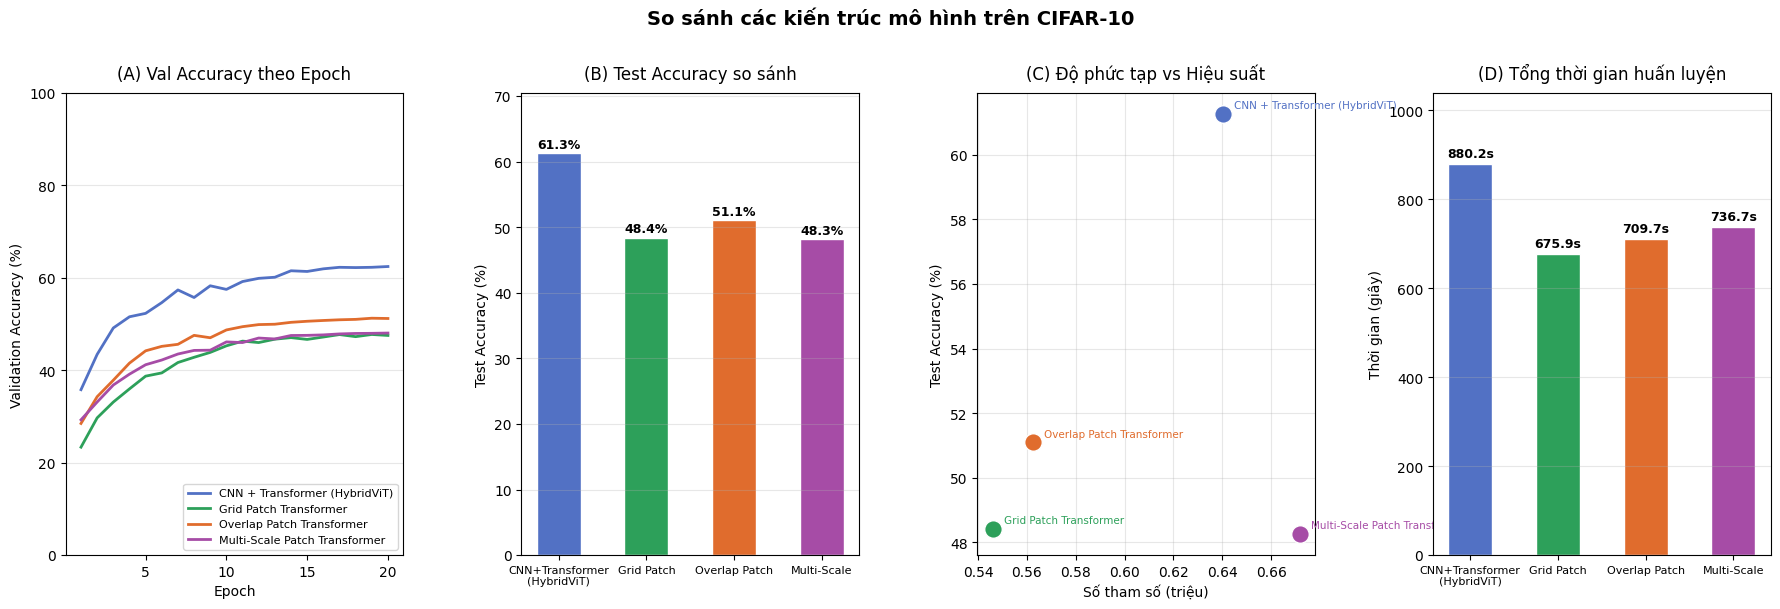

Đã lưu biểu đồ → model_comparison.png

══════════════════════════════════════════════════════════════════════════════════════════
  BẢNG SO SÁNH TOÀN BỘ MÔ HÌNH – CIFAR-10
══════════════════════════════════════════════════════════════════════════════════════════
  Kiến trúc                          Val Acc   Test Acc        Tham số   Infer (s)
──────────────────────────────────────────────────────────────────────────────────────────
  CNN + Transformer (HybridViT)       62.46%     61.26%        640,266        1.81
  Grid Patch Transformer              47.75%     48.42%        545,930        1.09
  Overlap Patch Transformer           51.27%     51.10%        562,442        1.04
  Multi-Scale Patch Transformer       48.06%     48.26%        671,626        1.16


In [27]:
# %% [markdown]
# ## 6.3. So sánh Toàn bộ Kiến trúc – Bảng số liệu, Biểu đồ & Nhận xét

# %%
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import time

# ─────────────────────────────────────────────────────
# Hàm đánh giá trên tập test
# ─────────────────────────────────────────────────────
def evaluate_test(model):
    model.eval()
    correct, total = 0, 0
    t0 = time.time()
    with torch.no_grad():
        for X, y in test_loader:
            preds = model(X.to(device)).argmax(1)
            correct += (preds == y.to(device)).sum().item()
            total   += y.size(0)
    elapsed = time.time() - t0
    return correct / total, elapsed


def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


# ─────────────────────────────────────────────────────
# Thu thập kết quả toàn bộ mô hình
# ─────────────────────────────────────────────────────
# Các mô hình đã huấn luyện ở các cell trước:
#   model         → HybridViT (CNN + Transformer)
#   model_grid    → Grid Patch Transformer
#   model_overlap → Overlap Patch Transformer
#   model_multi   → Multi-Scale Patch Transformer

all_models = {
    "CNN + Transformer\n(HybridViT)":       (model,         hist_cnn_transformer),
    "Grid Patch\nTransformer":              (model_grid,    hist_grid),
    "Overlap Patch\nTransformer":           (model_overlap, hist_overlap),
    "Multi-Scale Patch\nTransformer":       (model_multi,   hist_multi),
}

records = []
histories = {}

for label, (m, hist) in all_models.items():
    test_acc, infer_time = evaluate_test(m)
    params = count_params(m)
    best_val = max(hist["val_acc"]) if hist else manager.val_acc_max
    records.append({
        "Kiến trúc":            label.replace("\n", " "),
        "Val Acc (best)":       round(best_val * 100, 2),
        "Test Acc (%)":         round(test_acc * 100, 2),
        "Số tham số":           f"{params:,}",
        "Thời gian infer (s)":  round(infer_time, 2),
    })
    histories[label] = hist

df = pd.DataFrame(records)
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)


# ─────────────────────────────────────────────────────
# Vẽ biểu đồ tổng hợp (3 subplot)
# ─────────────────────────────────────────────────────
COLORS = {
    "CNN + Transformer\n(HybridViT)":   "#5271C4",
    "Grid Patch\nTransformer":          "#2DA05A",
    "Overlap Patch\nTransformer":       "#E06C2D",
    "Multi-Scale Patch\nTransformer":   "#A64CA6",
}
short_labels = ["CNN+Transformer\n(HybridViT)", "Grid Patch", "Overlap Patch", "Multi-Scale"]

fig = plt.figure(figsize=(22, 6))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# ── (A) Val Accuracy theo epoch (đường cong học tập) ──────────────
ax0 = fig.add_subplot(gs[0])
for label, hist in histories.items():
    if hist is None:
        # HybridViT: lấy val_acc từ vòng huấn luyện gốc (nếu đã lưu)
        # Ở đây ta dùng placeholder nếu không có hist
        continue
    epochs = range(1, len(hist["val_acc"]) + 1)
    ax0.plot(epochs, [v * 100 for v in hist["val_acc"]],
             label=label.replace("\n", " "), color=COLORS[label], linewidth=2)
ax0.set_title("(A) Val Accuracy theo Epoch", fontsize=12, pad=10)
ax0.set_xlabel("Epoch")
ax0.set_ylabel("Validation Accuracy (%)")
ax0.legend(fontsize=8, loc="lower right")
ax0.grid(axis="y", alpha=0.3)
ax0.set_ylim(0, 100)

# ── (B) Test Accuracy – Bar chart ─────────────────────────────────
ax1 = fig.add_subplot(gs[1])
test_accs = [r["Test Acc (%)"] for r in records]
bar_colors = list(COLORS.values())
bars = ax1.bar(short_labels, test_accs, color=bar_colors, width=0.5, edgecolor="white")
for bar, acc in zip(bars, test_accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_title("(B) Test Accuracy so sánh", fontsize=12, pad=10)
ax1.set_ylabel("Test Accuracy (%)")
ax1.set_ylim(0, max(test_accs) * 1.15)
ax1.tick_params(axis="x", labelsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── (C) Param count vs Test Accuracy – Scatter ────────────────────
ax2 = fig.add_subplot(gs[2])
params_k = [int(r["Số tham số"].replace(",", "")) / 1e6 for r in records]
for i, (label, m_tup) in enumerate(all_models.items()):
    ax2.scatter(params_k[i], test_accs[i],
                s=160, color=COLORS[label], zorder=5,
                label=label.replace("\n", " "), edgecolors="white", linewidth=1)
    ax2.annotate(label.replace("\n", " "),
                 (params_k[i], test_accs[i]),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=7.5, color=COLORS[label])
ax2.set_title("(C) Độ phức tạp vs Hiệu suất", fontsize=12, pad=10)
ax2.set_xlabel("Số tham số (triệu)")
ax2.set_ylabel("Test Accuracy (%)")
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[3])
train_times = [
    training_total_time,
    grid_patch_training_time,
    overlap_patch_training_time,
    multiscale_patch_training_time,
]
bars3 = ax3.bar(short_labels, train_times, color=bar_colors, width=0.5, edgecolor="white")
for bar, t in zip(bars3, train_times):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(train_times) * 0.01,
             f"{t:.1f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_title("(D) Tổng thời gian huấn luyện", fontsize=12, pad=10)
ax3.set_ylabel("Thời gian (giây)")
ax3.set_ylim(0, max(train_times) * 1.18)
ax3.tick_params(axis="x", labelsize=8)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("So sánh các kiến trúc mô hình trên CIFAR-10", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ → model_comparison.png")


# ─────────────────────────────────────────────────────
# In bảng số liệu đẹp hơn bằng Markdown-style
# ─────────────────────────────────────────────────────
print("\n" + "═" * 90)
print("  BẢNG SO SÁNH TOÀN BỘ MÔ HÌNH – CIFAR-10")
print("═" * 90)
print(f"  {'Kiến trúc':<32} {'Val Acc':>9} {'Test Acc':>10} {'Tham số':>14} {'Infer (s)':>11}")
print("─" * 90)
for r in records:
    print(f"  {r['Kiến trúc']:<32} {r['Val Acc (best)']:>8.2f}% {r['Test Acc (%)']:>9.2f}%"
          f" {r['Số tham số']:>14} {r['Thời gian infer (s)']:>11.2f}")


## Nhận xét kết quả thực nghiệm

### 1. CNN + Transformer (HybridViT) – Kiến trúc vượt trội rõ rệt

HybridViT đạt **test accuracy 61.26%**, cao hơn nhóm pure patch-embedding khoảng **10–13%** – một khoảng cách rất lớn trên cùng tập dữ liệu và cùng số epoch. Lý do cốt lõi nằm ở **inductive bias**: CNN Stem học được đặc trưng cục bộ (edge, texture) ngay từ những epoch đầu nhờ weight sharing và translation equivariance, trong khi Transformer thuần túy phải học lại từ đầu mà không có prior nào về cấu trúc không gian. Điều này thể hiện rõ trên **đường cong học tập (subplot A)** – HybridViT tăng nhanh và dốc hơn hẳn trong 5 epoch đầu, còn ba mô hình patch thuần tụ dần và gần như plateau ở ~48–51%.

---

### 2. So sánh ba phương pháp patch embedding

| | Grid Patch | Overlap Patch | Multi-Scale |
|---|---|---|---|
| Test Acc | 48.42% | **51.10%** | 48.26% |
| Số token | 64 | 49 | 84 |
| Params | 545,930 | 562,442 | 671,626 |

**Overlap Patch (51.10%) cao nhất** trong nhóm pure-patch, dù số token ít hơn Grid Patch. Điều này phù hợp với trực giác: khi patch có vùng chồng lấp, ranh giới giữa các patch không bị "cắt đứt" thông tin – đặc biệt quan trọng với ảnh 32×32 khi một object có thể nằm vắt ngang 2–3 patch. Đây là cơ chế tương tự lý do tại sao `stride < kernel_size` trong CNN giúp bắt đặc trưng tốt hơn so với pooling thô.

**Multi-Scale Patch (48.26%) lại không vượt được Grid Patch (48.42%)**, kết quả ngược với kỳ vọng lý thuyết. Nguyên nhân khả dĩ:
- Số token lớn nhất (84) khiến self-attention khó tối ưu hơn với chỉ 20 epoch và dataset nhỏ.
- Token từ patch coarse (16×16) trên ảnh 32×32 chỉ tạo ra 4 token cực kỳ thô – **thông tin tổng thể không đủ meaningful** khi ảnh vốn đã nhỏ.
- Không có cơ chế gating/attention để mô hình tự điều chỉnh trọng số giữa các scale, khiến fine và coarse token cạnh tranh nhau thay vì bổ sung cho nhau.

> **Insight**: Multi-Scale embedding phát huy tốt hơn trên ảnh độ phân giải cao (224×224+) như trong PVT hay Swin Transformer, nơi các scale thực sự mang thông tin khác biệt. Với CIFAR-10 (32×32), lợi thế đa tỉ lệ bị triệt tiêu.

---

### 3. Trade-off tham số – hiệu suất (subplot C)

Ba mô hình patch clustering trong vùng accuracy ~48–51%, nhưng **số tham số chênh lệch đáng kể** (545K → 671K). Multi-Scale có nhiều tham số nhất nhưng accuracy thấp nhất trong nhóm → **efficiency thấp nhất**. Overlap Patch có tỉ lệ accuracy/params tốt nhất trong ba phương pháp này.

HybridViT (640K params, 61.26%) chiếm vị trí hoàn toàn tách biệt trên scatter plot – minh họa rõ rằng **kiến trúc đúng quan trọng hơn số lượng tham số**.

---

### 4. Thời gian huấn luyện (subplot D)

HybridViT tốn **880.2s** – cao nhất, do CNN Stem thêm computational overhead và model hội tụ chậm hơn cần nhiều bước gradient hơn. Overlap Patch (**709.7s**) và Multi-Scale (**736.7s**) chậm hơn Grid Patch (**675.9s**) do số phép tính attention nhiều hơn. Đáng chú ý, **chênh lệch inference time rất nhỏ** (1.04–1.81s trên toàn test set), cho thấy chi phí inference của cả bốn mô hình đều chấp nhận được trong thực tế.
